# 📊 YouTube en LATAM y su relación con la felicidad

Este análisis explora tres preguntas:

1. ¿Cómo varía el uso de YouTube (usuarios totales y tasa de penetración) entre los países de Latinoamérica?
2. ¿Existe relación entre la penetración de YouTube y el puntaje de felicidad de un país (*Life Ladder*, del World Happiness Report)?
3. ¿Qué países combinan alto potencial económico/social pero baja penetración de YouTube respecto al uso general de redes sociales? (Índice de Oportunidad Digital)

**Fuentes de datos:**
- [YouTube Users by Country 2025](https://www.kaggle.com/datasets/arpitsinghaiml/youtube-user-by-country-2025) (Kaggle)
- [World Happiness Report 2024](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated) (Kaggle)
- [Social Media Users by Country](https://www.kaggle.com/datasets/edissoniiguez/social-media-users) (Kaggle)

> Los CSV no se incluyen en este repositorio por su tamaño y licencia. Ver `data/README.md` para instrucciones de descarga.


## 1. Librerías y configuración

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")

# Rutas de datos locales (ver data/README.md para descargarlos)
PATH_YOUTUBE = "../data/youtube-users-by-country-2025.csv"
PATH_HAPPINESS = "../data/world-happiness-report-updated_2024.csv"
PATH_SOCIAL = "../data/usuarios-de-redes-sociales-por-pais-en-2026.csv"


## 2. Uso de YouTube en países de Latinoamérica

Cargamos el dataset de usuarios de YouTube y filtramos únicamente los países de LATAM.

In [16]:
yt_df = pd.read_csv(PATH_YOUTUBE)

latam_countries = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Costa Rica",
    "Dominican Republic", "Ecuador", "El Salvador", "Guatemala", "Honduras",
    "Mexico", "Nicaragua", "Panama", "Paraguay", "Peru", "Uruguay", "Venezuela",
]

latam_df = yt_df[yt_df["country"].isin(latam_countries)].copy()
latam_df.head()


,flagCode,country,YouTubeUsers_TotalUsers_Num_2024Feb,YouTubeUsers_Penetration_Pct_2024Feb,YouTubeUsersJuly2023,YouTubeUsersPenetrationJuly2023
2,BR,Brazil,144000000,76.6,142.0,72.9
4,MX,Mexico,83100000,77.5,81.8,71.1
19,AR,Argentina,31300000,77.1,31.8,77.6
20,CO,Colombia,30300000,76.7,30.7,64.2
33,PE,Peru,17600000,68.3,17.6,57.3


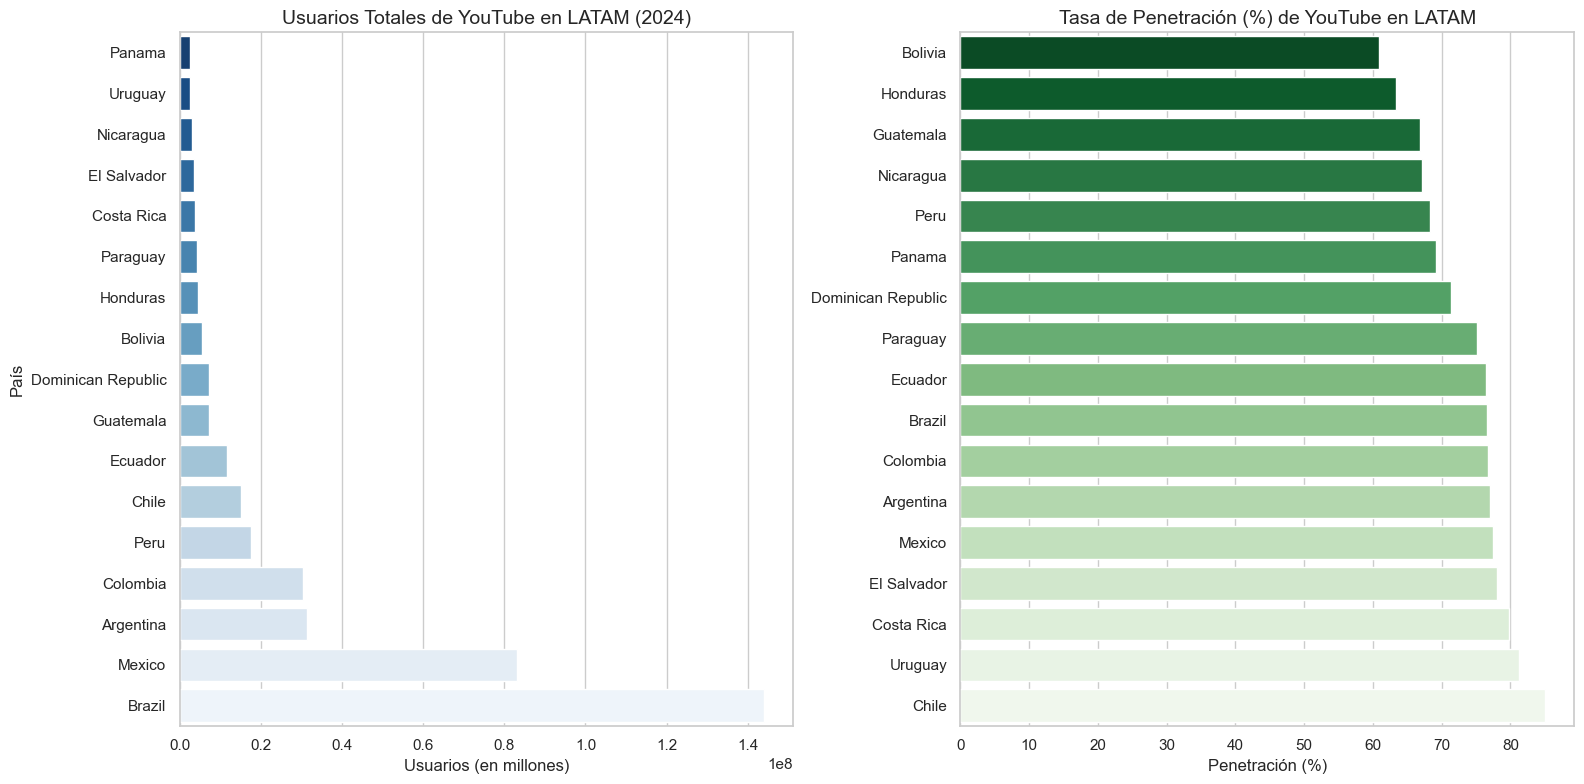

In [17]:
df_users = latam_df.sort_values(by="YouTubeUsers_TotalUsers_Num_2024Feb", ascending=True)
df_penetration = latam_df.sort_values(by="YouTubeUsers_Penetration_Pct_2024Feb", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    ax=axes[0], data=df_users,
    x="YouTubeUsers_TotalUsers_Num_2024Feb", y="country",
    palette="Blues_r", hue="country", legend=False,
)
axes[0].set_title("Usuarios Totales de YouTube en LATAM (2024)", fontsize=14)
axes[0].set_xlabel("Usuarios (en millones)")
axes[0].set_ylabel("País")

sns.barplot(
    ax=axes[1], data=df_penetration,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="country",
    palette="Greens_r", hue="country", legend=False,
)
axes[1].set_title("Tasa de Penetración (%) de YouTube en LATAM", fontsize=14)
axes[1].set_xlabel("Penetración (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/01_youtube_latam.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Penetración de YouTube vs. Felicidad (Life Ladder)

Unimos el dataset de YouTube con el World Happiness Report para explorar si hay correlación
entre el porcentaje de la población que usa YouTube y el puntaje de felicidad de cada país.

In [18]:
whr_df = pd.read_csv(PATH_HAPPINESS, encoding="latin-1")

# Estandarización de nombres para el JOIN
whr_df["Country name"] = whr_df["Country name"].replace({
    "United States": "United States of America",
    "Czechia": "Czech Republic",
    "Taiwan Province of China": "Taiwan",
})

merged_df = pd.merge(
    yt_df, whr_df,
    left_on="country", right_on="Country name",
    how="inner",
)

corr_pearson = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].corr(merged_df["Life Ladder"], method="pearson")
corr_spearman = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].corr(merged_df["Life Ladder"], method="spearman")

print(f"Coeficiente de Pearson:  {corr_pearson:.4f}")
print(f"Coeficiente de Spearman: {corr_spearman:.4f}")


Coeficiente de Pearson:  0.5232
Coeficiente de Spearman: 0.5246


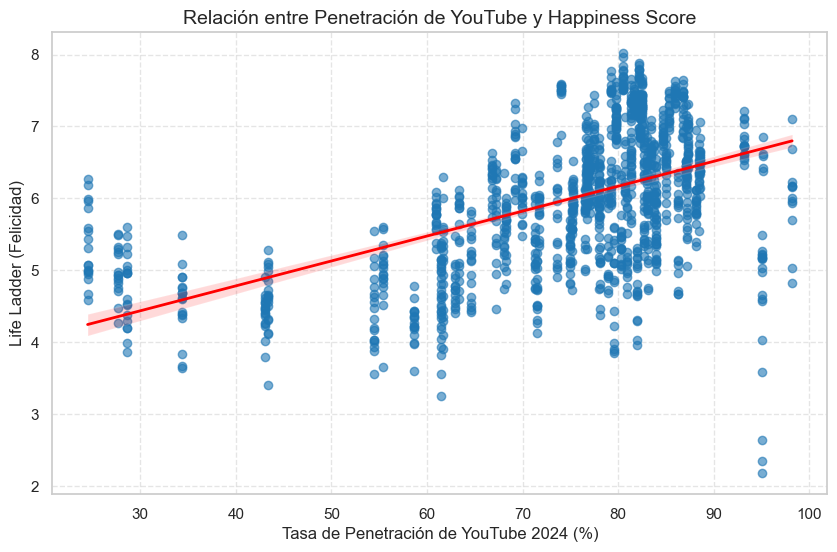

In [19]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("Relación entre Penetración de YouTube y Happiness Score", fontsize=14)
plt.xlabel("Tasa de Penetración de YouTube 2024 (%)", fontsize=12)
plt.ylabel("Life Ladder (Felicidad)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("../outputs/figures/02_penetracion_vs_felicidad.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretación:** una correlación de Pearson de ~0.52 sugiere una relación positiva moderada:
los países con mayor penetración de YouTube tienden a reportar puntajes de felicidad más altos.
Esto **no implica causalidad** — probablemente ambas variables estén asociadas con un tercer factor,
como el desarrollo económico o el acceso a infraestructura digital.

## 4. Índice de Oportunidad Digital

Combinamos tres fuentes (YouTube, felicidad y redes sociales en general) para construir un índice
que resalta países con alto potencial (buen PIB, buena felicidad, alto uso general de redes) pero
que aún tienen una penetración de YouTube relativamente baja — es decir, mercados con espacio
para crecer.

In [20]:
social_df = pd.read_csv(PATH_SOCIAL)

whr_recent = whr_df[whr_df["year"] == 2023]  # ajustar si hay un año más reciente disponible

df_advanced = pd.merge(yt_df, whr_recent, left_on="country", right_on="Country name", how="inner")
df_advanced = pd.merge(df_advanced, social_df, on="country", how="inner")

df_advanced["gap_youtube_vs_redes"] = (
    df_advanced["SocialMediaUsersPctOfPopulation_2025"]
    - df_advanced["YouTubeUsers_Penetration_Pct_2024Feb"]
)

cols_to_normalize = [
    "Life Ladder", "Log GDP per capita",
    "YouTubeUsers_Penetration_Pct_2024Feb", "gap_youtube_vs_redes",
]
df_advanced = df_advanced.dropna(subset=cols_to_normalize)

scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_advanced[cols_to_normalize])
df_advanced["felicidad_norm"] = normalized[:, 0]
df_advanced["GDP_norm"] = normalized[:, 1]
df_advanced["penetracion_norm"] = normalized[:, 2]
df_advanced["gap_norm"] = normalized[:, 3]

df_advanced["indice_oportunidad"] = (
    df_advanced["felicidad_norm"] + df_advanced["GDP_norm"] + df_advanced["gap_norm"]
) - df_advanced["penetracion_norm"]

top_10_potencial = df_advanced.sort_values(by="indice_oportunidad", ascending=False).head(10)
top_10_potencial[["country", "indice_oportunidad"]]


,country,indice_oportunidad
26,Philippines,1.890970
20,Saudi Arabia,1.609724
78,Iceland,1.558441
63,Ireland,1.406260
54,Denmark,1.347322
48,Switzerland,1.322037
67,Kuwait,1.297615
56,Norway,1.262228
37,United Arab Emirates,1.257928
58,Finland,1.232803


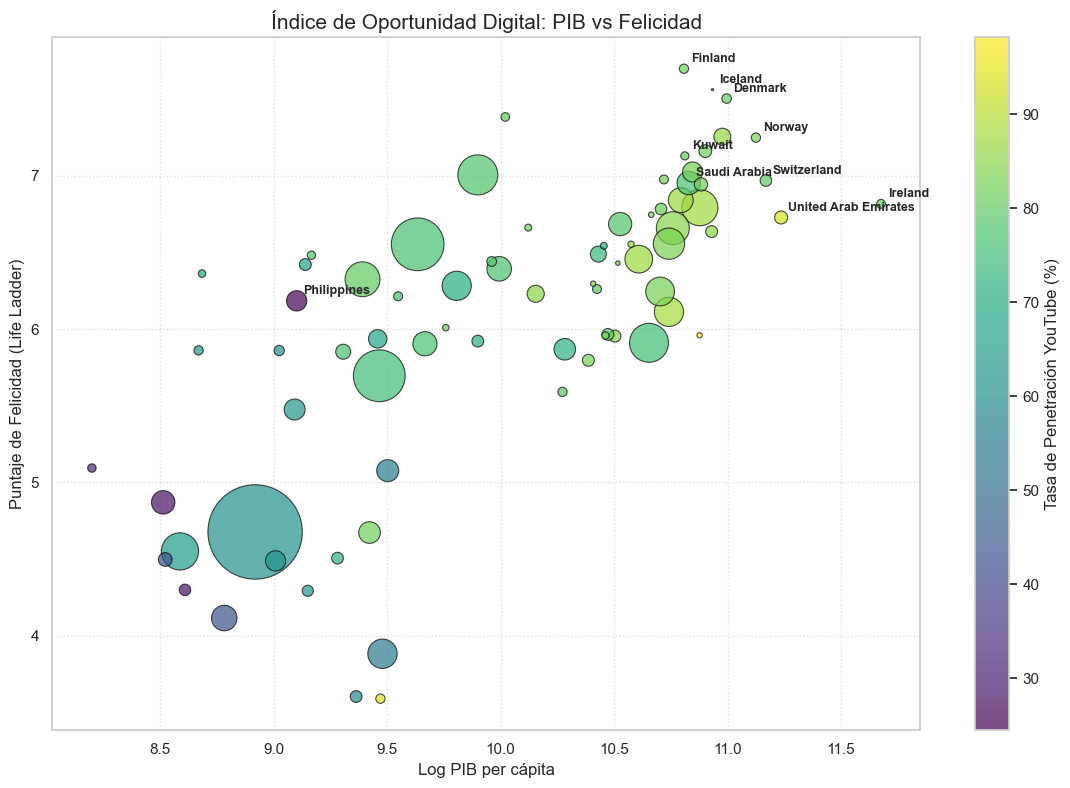

In [21]:
plt.figure(figsize=(14, 9))
scatter = plt.scatter(
    x=df_advanced["Log GDP per capita"],
    y=df_advanced["Life Ladder"],
    s=df_advanced["YouTubeUsers_TotalUsers_Num_2024Feb"] / 1e5,
    c=df_advanced["YouTubeUsers_Penetration_Pct_2024Feb"],
    cmap="viridis", alpha=0.7, edgecolors="black", linewidth=0.8,
)
cbar = plt.colorbar(scatter)
cbar.set_label("Tasa de Penetración YouTube (%)")

for _, row in top_10_potencial.iterrows():
    plt.annotate(
        row["country"],
        (row["Log GDP per capita"], row["Life Ladder"]),
        fontsize=9, fontweight="bold",
        xytext=(5, 5), textcoords="offset points",
    )

plt.title("Índice de Oportunidad Digital: PIB vs Felicidad", fontsize=15)
plt.xlabel("Log PIB per cápita", fontsize=12)
plt.ylabel("Puntaje de Felicidad (Life Ladder)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("../outputs/figures/03_indice_oportunidad_digital.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
print(top_10_potencial[[
    "country", "indice_oportunidad",
    "YouTubeUsers_TotalUsers_Num_2024Feb",
    "YouTubeUsers_Penetration_Pct_2024Feb",
    "SocialMediaUsersPctOfPopulation_2025",
    "gap_youtube_vs_redes",
    "Life Ladder",
]].to_string(index=False))


             country  indice_oportunidad  YouTubeUsers_TotalUsers_Num_2024Feb  YouTubeUsers_Penetration_Pct_2024Feb  SocialMediaUsersPctOfPopulation_2025  gap_youtube_vs_redes  Life Ladder
         Philippines            1.890970                             21350000                                  24.5                                  81.9                  57.4        6.184
        Saudi Arabia            1.609724                             28300000                                  76.8                                 111.0                  34.2        6.953
             Iceland            1.558441                               276000                                  74.0                                  83.9                   9.9        7.562
             Ireland            1.406260                              4010000                                  79.8                                  80.1                   0.3        6.817
             Denmark            1.347322               

## 5. Conclusiones

- La penetración de YouTube varía considerablemente dentro de LATAM, sin una relación directa
  con el tamaño poblacional de cada país.
- Existe una correlación positiva moderada (~0.52) entre penetración de YouTube y felicidad,
  probablemente mediada por el desarrollo económico y el acceso a infraestructura digital.
- El Índice de Oportunidad Digital identifica países con alto potencial socioeconómico pero
  relativamente baja penetración de YouTube frente al uso general de redes sociales — posibles
  mercados con espacio de crecimiento para la plataforma.

**Próximos pasos posibles:** incorporar series temporales para ver evolución año a año, o
desagregar por franja etaria si el dataset lo permite.
